In [33]:
import os #file & path handling
import numpy as np # numerical computations
import cv2 # image reading and processing
import matplotlib.pyplot as plt # visualization
import tensorflow as tf # deeplearning framework

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as res_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess


In [34]:
TRAIN_DIR = "Data set/Training"
TEST_DIR  = "Data set/Testing"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16
NUM_CLASSES = 4


In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
preprocess_input = tf.keras.applications.efficientnet.preprocess_input
preprocess_input = tf.keras.applications.resnet50.preprocess_input
preprocess_input = tf.keras.applications.densenet.preprocess_input

#Data Augumentation to prevent overfitting and improves generalization
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)


test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Loading training data
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

# Loading testing data
test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


CLASS_NAMES = list(train_data.class_indices.keys())
print("Classes:", CLASS_NAMES)


Found 5714 images belonging to 4 classes.
Found 1314 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [36]:
def build_model(base_model):
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [37]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications import EfficientNetB0


efficientnet_model = build_model(
    EfficientNetB0(weights="imagenet", include_top=False,
                   input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
)

resnet_model = build_model(
    ResNet50(weights="imagenet", include_top=False,
             input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
)

densenet_model = build_model(
    DenseNet121(weights="imagenet", include_top=False,
                input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
)

efficientnet_model.fit(train_data, epochs=15, validation_data=test_data)
resnet_model.fit(train_data, epochs=15, validation_data=test_data)
densenet_model.fit(train_data, epochs=15, validation_data=test_data)


Epoch 1/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 293s 747ms/step - accuracy: 0.6190 - loss: 0.8885 - val_accuracy: 0.2291 - val_loss: 1.4003
Epoch 2/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 219s 611ms/step - accuracy: 0.7112 - loss: 0.7068 - val_accuracy: 0.2291 - val_loss: 1.4907
Epoch 3/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 205s 573ms/step - accuracy: 0.7408 - loss: 0.6330 - val_accuracy: 0.2291 - val_loss: 1.6889
Epoch 4/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 198s 554ms/step - accuracy: 0.7522 - loss: 0.5901 - val_accuracy: 0.2291 - val_loss: 1.5861
Epoch 5/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 223s 623ms/step - accuracy: 0.7737 - loss: 0.5637 - val_accuracy: 0.2291 - val_loss: 1.6607
Epoch 6/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 220s 615ms/step - accuracy: 0.7786 - loss: 0.5335 - val_accuracy: 0.3135 - val_loss: 1.5529
Epoch 7/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 287s 801ms/step - accuracy: 0.8012 - loss: 0.5035 - val_accuracy: 0.4467 - val_loss: 1.5577
Epoch 8/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 211s 590ms/step - accuracy: 0.8096 -

In [39]:
efficientnet_model.save("efficientnet_model.h5")
resnet_model.save("resnet_model.h5")
densenet_model.save("densenet_model.h5")


In [54]:
efficientnet_model = tf.keras.models.load_model("efficientnet_model.h5")
resnet_model = tf.keras.models.load_model("resnet_model.h5")
densenet_model = tf.keras.models.load_model("densenet_model.h5")

MODELS = {
    "EfficientNet": efficientnet_model,
    "ResNet50": resnet_model,
    "DenseNet121": densenet_model
}


In [55]:
def load_image(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError("Image path does not exist")

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Unable to read image")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    return img


In [56]:
def preprocess_for_model(img, model_name):
    img = np.expand_dims(img, axis=0).astype(np.float32)

    if model_name == "EfficientNet":
        return eff_preprocess(img)
    elif model_name == "ResNet50":
        return res_preprocess(img)
    else:
        return dense_preprocess(img)


In [57]:
def predict(model, img, model_name):
    processed = preprocess_for_model(img, model_name)
    preds = model.predict(processed)
    class_idx = np.argmax(preds)
    return CLASS_NAMES[class_idx], preds[0][class_idx]


In [58]:
def generate_gradcam(model, img_array, last_conv_layer):
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)

    if grads is None:
        raise ValueError("Gradients are None. Check preprocessing.")

   
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]                
    pooled_grads = pooled_grads           

    
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()


In [59]:
def focus_score(heatmap):
    return np.mean(heatmap)

def coverage_score(heatmap, threshold=0.5):
    return np.sum(heatmap > threshold) / heatmap.size


In [60]:
def heatmap_quality_score(heatmap):
    focus = np.mean(heatmap)
    coverage = np.sum(heatmap > 0.5) / heatmap.size

    compactness = focus / (coverage + 1e-6)

    return compactness


In [100]:
def analyze_mri(image_path, tumor_conf_threshold=0.6):


    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_norm = img / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    LAST_CONV_LAYERS = {
        "EfficientNet": "top_conv",
        "ResNet50": "conv5_block3_out",
        "DenseNet121": "conv5_block16_concat"
    }

    results = {}
    tumor_candidates = {}

    for name, model in MODELS.items():

        preds = model.predict(img_input, verbose=0)[0]
        class_idx = np.argmax(preds)
        confidence = preds[class_idx]
        pred_class = CLASS_NAMES[class_idx]

        results[name] = {
            "class": pred_class,
            "confidence": confidence
        }

        
        if pred_class != "notumor" and confidence >= tumor_conf_threshold:
            tumor_candidates[name] = confidence

    
    if len(tumor_candidates) == 0:
        print("\n No tumor detected")
        print("All models predict normal MRI or low tumor confidence.\n")

    
        for name, model in MODELS.items():
            heatmap = generate_gradcam(
                model,
                img_input,
                LAST_CONV_LAYERS[name]
            )

            show_heatmap(img, heatmap, f"{name} Grad-CAM")

            print(f"{name}")
            print(f"Predicted Class : {results[name]['class']}")
            print(f"Confidence      : {results[name]['confidence']:.4f}\n")

        return

    
    print("\n Tumor detected ")
    print("Explainable analysis for all models\n")

    explain_results = {}

    for name, model in MODELS.items():

        heatmap = generate_gradcam(
            model,
            img_input,
            LAST_CONV_LAYERS[name]
        )

        focus = np.mean(heatmap)
        coverage = np.sum(heatmap > 0.5) / heatmap.size
        sharpness = focus / (coverage + 1e-6)
        sharpness_norm = sharpness / (sharpness + 1)

        confidence = results[name]["confidence"]
        pred_class = results[name]["class"]

        explain_score = (
            0.7 * confidence +
            0.3 * sharpness_norm
        )

        explain_results[name] = {
            "class": pred_class,
            "confidence": confidence,
            "focus": focus,
            "coverage": coverage,
            "sharpness": sharpness,
            "score": explain_score,
            "heatmap": heatmap
        }

        
        show_heatmap(img, heatmap, f"{name} Grad-CAM")

        print(f"{name}")
        print(f"Predicted Class : {pred_class}")
        print(f"Confidence      : {confidence:.4f}")
        print(f"Focus           : {focus:.4f}")
        print(f"Sharpness       : {sharpness:.4f}")
        print(f"Explain Score   : {explain_score:.4f}\n")

   
    tumor_models = {
        k: v for k, v in explain_results.items()
        if v["class"] != "notumor"
    }

    best_model = max(
        tumor_models,
        key=lambda x: tumor_models[x]["score"]
    )

    print(f" Recommended Model: {best_model}")


Enter MRI image path:  Data set/Testing/glioma/Te-gl_0135.jpg



 Tumor detected 
Explainable analysis for all models



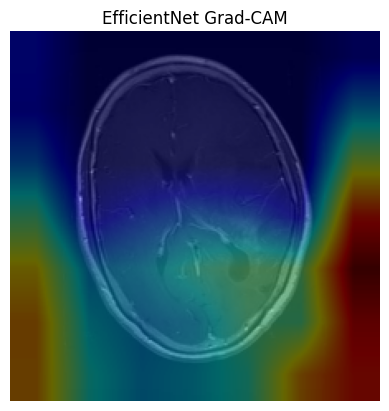

EfficientNet
Predicted Class : notumor
Confidence      : 0.5385
Focus           : 0.2963
Sharpness       : 1.6132
Explain Score   : 0.5621



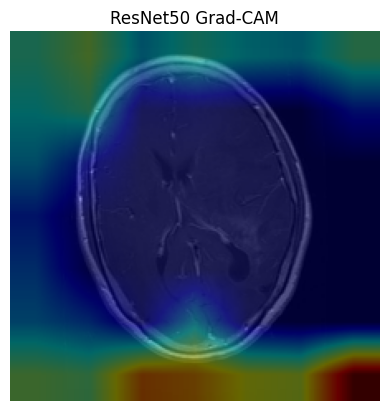

ResNet50
Predicted Class : glioma
Confidence      : 0.4642
Focus           : 0.2121
Sharpness       : 1.4844
Explain Score   : 0.5042



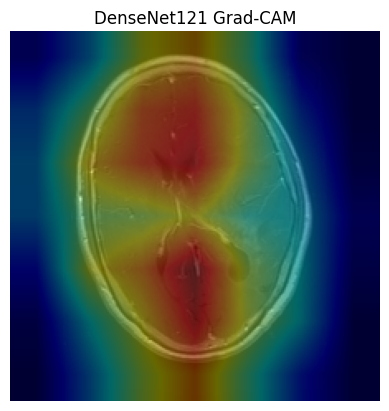

DenseNet121
Predicted Class : glioma
Confidence      : 0.9999
Focus           : 0.4128
Sharpness       : 0.9632
Explain Score   : 0.8471

 Recommended Model: DenseNet121


In [101]:
# testing of glioma
image_path = input("Enter MRI image path: ").strip()
analyze_mri(image_path)


Enter MRI image path:  Data set/Testing/meningioma/Te-me_0274.jpg



 Tumor detected 
Explainable analysis for all models



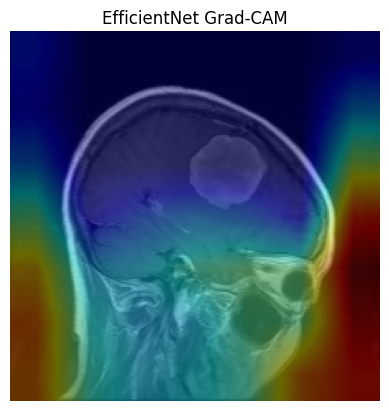

EfficientNet
Predicted Class : notumor
Confidence      : 0.5235
Focus           : 0.3030
Sharpness       : 1.6498
Explain Score   : 0.5533



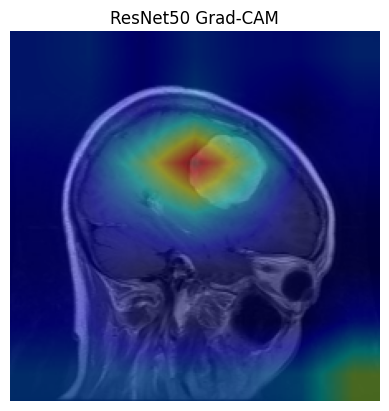

ResNet50
Predicted Class : glioma
Confidence      : 0.8414
Focus           : 0.1666
Sharpness       : 4.0821
Explain Score   : 0.8300



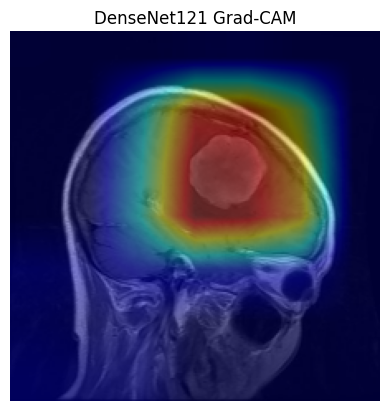

DenseNet121
Predicted Class : meningioma
Confidence      : 1.0000
Focus           : 0.2011
Sharpness       : 1.0951
Explain Score   : 0.8568

 Recommended Model: DenseNet121


In [102]:
image_path = input("Enter MRI image path: ").strip()
analyze_mri(image_path)


Enter MRI image path:  Data set/Testing/notumor/Te-noTr_0009.jpg



 No tumor detected
All models predict normal MRI or low tumor confidence.



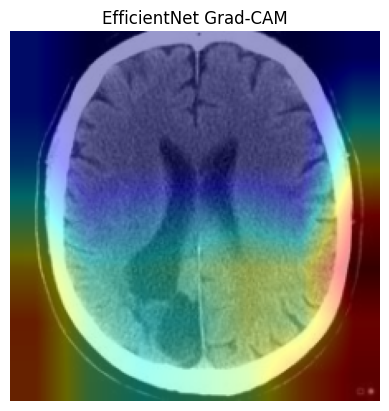

EfficientNet
Predicted Class : notumor
Confidence      : 0.6612



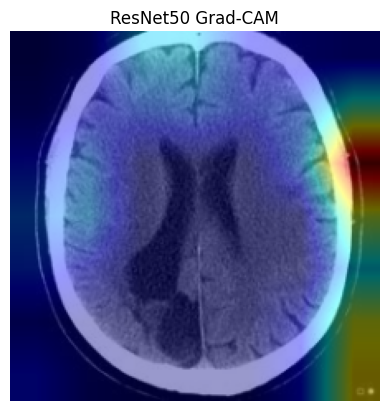

ResNet50
Predicted Class : pituitary
Confidence      : 0.5499



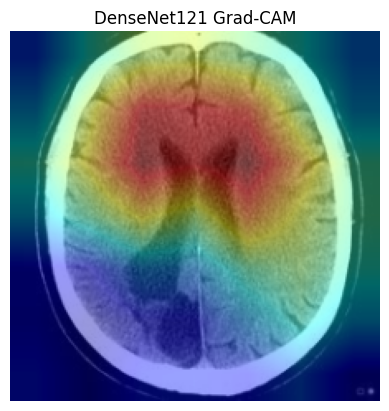

DenseNet121
Predicted Class : notumor
Confidence      : 1.0000



In [116]:
image_path = input("Enter MRI image path: ").strip()
analyze_mri(image_path)



Enter MRI image path:  Data set/Testing/pituitary/Te-piTr_0006.jpg



 Tumor detected 
Explainable analysis for all models



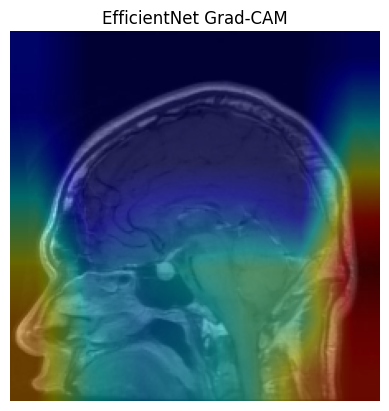

EfficientNet
Predicted Class : notumor
Confidence      : 0.5417
Focus           : 0.2938
Sharpness       : 1.5997
Explain Score   : 0.5638



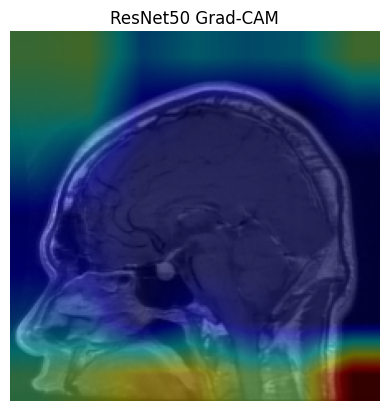

ResNet50
Predicted Class : glioma
Confidence      : 0.4427
Focus           : 0.2016
Sharpness       : 1.0976
Explain Score   : 0.4669



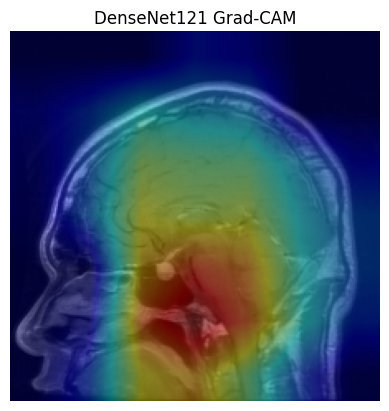

DenseNet121
Predicted Class : pituitary
Confidence      : 0.8178
Focus           : 0.3003
Sharpness       : 1.2260
Explain Score   : 0.7377

 Recommended Model: DenseNet121


In [124]:
image_path = input("Enter MRI image path: ").strip()
analyze_mri(image_path)
